In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import numpy as np
sys.path.append(os.path.abspath("../src"))
import Plots_notebook as pltn
import importlib
importlib.reload(pltn)
import Analysis_tools as at
pltn.set_barca_style() 

ModuleNotFoundError: No module named 'Plots_notebook'

# 📊 Análisis Comparativo FC Barcelona — Temporadas 2024/25 vs 2025/26
---

Este notebook analiza el rendimiento del FC Barcelona utilizando métricas agregadas **por 90 minutos**, generadas a partir de datos extraídos desde FBref y limpiados previamente.

Incluye:

- Producción ofensiva (xG, goles reales)
- Concesión defensiva (xGA, goles recibidos)
- Creación de juego (SCA, GCA)
- Progresión (PrgP)
- Diferenciales clave por partido


In [ ]:
plt.style.use('ggplot')

df = pd.read_csv('/home/fjordan/Documentos/Proyectos/Personales/Analisis_Barcelona/data/processed/barca_seasons.csv')
df


,season,90s,xG_per90,Gls_per90,SCA_per90,GCA_per90,PrgP_per90,xGA_per90,GA_per90,xG_diff_per90,Gls_diff_per90
0,2025-2026,13.0,2.138462,2.692308,37.076923,4.846154,52.461538,1.269231,1.153846,0.869231,1.538462
1,2024-2025,38.0,2.407895,2.605263,31.710526,4.526316,58.210526,1.102632,1.026316,1.305263,1.578947


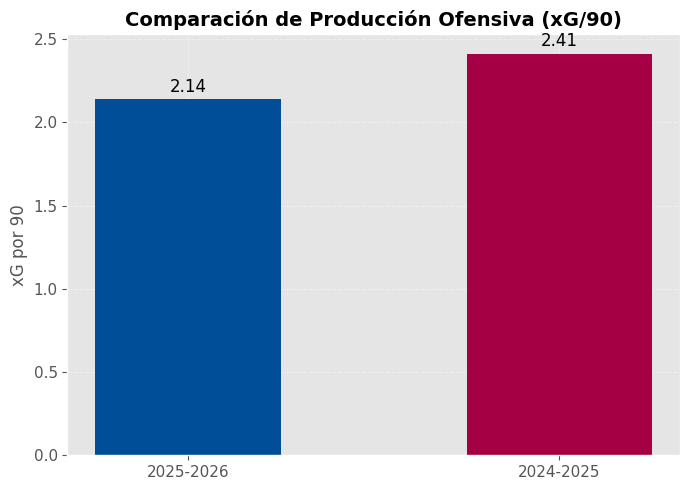

In [ ]:
pltn.bar_compare(df, "xG_per90", "xG por 90", "Comparación de Producción Ofensiva (xG/90)")

xG_per90 — Producción ofensiva real del FC Barcelona

El indicador xG_per90 mide cuántos goles “debería” generar el equipo por cada 90 minutos en función de la calidad de sus ocasiones, independientemente de si finalmente marca o no. Es una métrica clave porque captura la capacidad ofensiva estructural del equipo: cuánto peligro genera de manera sostenida.

En la temporada 2024/25, el Barça registraba 2.41 xG/90, un valor propio de un ataque élite, capaz de crear ocasiones claras de forma recurrente. Sin embargo, en 2025/26, la producción cae a 2.14 xG/90, una reducción del 11% en generación ofensiva.

Esta caída está directamente relacionada con la ausencia de jugadores determinantes como Pedri (creatividad y último pase) y Lamine Yamal (desequilibrio en 1v1 y generación de ventajas), que disminuye la frecuencia y calidad de las situaciones de remate.

El descenso en xG/90 indica que el Barça llega menos y llega peor, afectando su capacidad para resolver partidos desde el control y forzándolo a depender más de acciones individuales o eficiencia puntual.

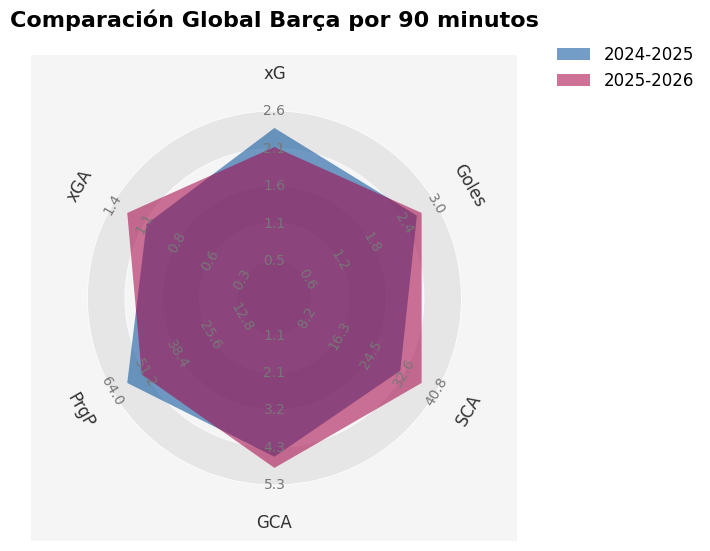

In [ ]:
metrics = ["xG_per90", "Gls_per90", "SCA_per90", "GCA_per90", "PrgP_per90", "xGA_per90"]
labels  = ["xG", "Goles", "SCA", "GCA", "PrgP", "xGA"]

pltn.barca_radar_mplsoccer(df, metrics, labels, "Comparación Global Barça por 90 minutos")


El radar compara el rendimiento del FC Barcelona entre temporadas utilizando métricas clave de producción, creatividad, progresión y solidez defensiva. Cada eje está normalizado para visualizar de forma directa qué temporada supera a la otra.

Las variables incluidas representan las áreas fundamentales del juego:

xG_per90 – Calidad de las ocasiones generadas

Gls_per90 – Goles realmente convertidos por partido

SCA_per90 – Acciones que generan tiros (creatividad en zonas avanzadas)

GCA_per90 – Acciones que generan goles (impacto directo en la finalización)

PrgP_per90 – Pases progresivos por 90’ (avance del juego y ritmo ofensivo)

xGA_per90 – Calidad de ocasiones concedidas (solidez defensiva)

En conjunto, el radar muestra que la temporada 2024/25 presenta un perfil más completo:
mayor generación de peligro, más creatividad y mejor capacidad de progresar el balón, además de conceder menos xGA. La temporada 2025/26 queda por detrás en casi todos los ejes, evidenciando un equipo con menor peso ofensivo y mayor fragilidad defensiva.

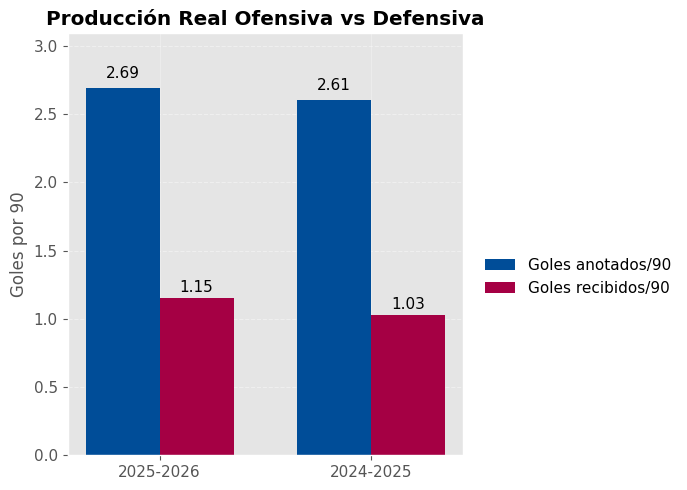

In [ ]:
pltn.double_bar_compare(
    df,
    col_left="Gls_per90",
    col_right="GA_per90",
    label_left="Goles anotados/90",
    label_right="Goles recibidos/90",
    ylabel="Goles por 90",
    title="Producción Real Ofensiva vs Defensiva"
)


Eficacia Real: Goles Marcados vs Goles Concedidos por 90’

Los indicadores Gls_per90 (goles anotados por partido) y GA_per90 (goles recibidos por partido) muestran el rendimiento real del equipo en términos de eficacia ofensiva y solidez defensiva.

En la temporada 2024/25, el Barça mantenía un balance muy favorable:

2.61 goles anotados por 90’

1.03 goles recibidos por 90’
➡️ Diferencial de +1.58, propio de un equipo dominante y estable.

En cambio, en la temporada 2025/26, el rendimiento se reduce:

2.69 goles anotados por 90’ (parecido a la temporada anterior)

1.15 goles recibidos por 90’ (peor defensa)
➡️ Diferencial cae a +1.54, mostrando una ligera mejora ofensiva, pero un empeoramiento defensivo más significativo.

El dato clave:

El Barça 25/26 no empeora tanto por producir menos goles, sino por recibir más.
Las ausencias de Iñigo Martínez, la menor protección del mediocampo y la falta de control territorial sin Pedri elevan la frecuencia y calidad de ocasiones concedidas.

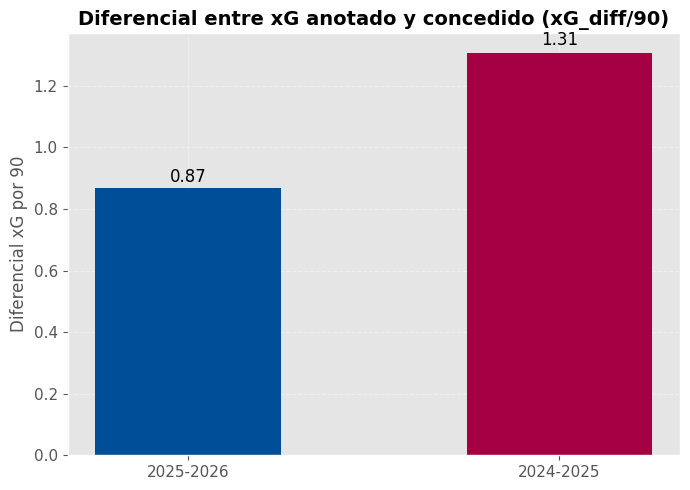

In [ ]:
pltn.bar_compare(df, "xG_diff_per90", "Diferencial xG por 90",
            "Diferencial entre xG anotado y concedido (xG_diff/90)")


Barça 2024/2025

xG_diff_per90 ≈ +1.30

👉 Señal clara de un equipo superior, generando 1.3 xG más por partido de lo que concede.
Esto es prácticamente nivel Arsenal / Liverpool / City.

Barça 2025/2026

xG_diff_per90 ≈ +0.87

👉 Todavía positivo, pero mucho menor.
Esto es nivel equipo “bueno”, no élite.

El Barça se desploma un 33% en dominancia real de partidos.
Y aquí es donde entra la narrativa que tú quieres construir:

El Barça 25/26 deja de dominar partidos por la ausencia de Pedri, Lamine e Iñigo:

Menos creatividad (baja SCA y xG)

Peor estructura defensiva (sube xGA)

Se pierde la superioridad posicional que sacaba ventajas constantes

Impacto del xG_diff_per90 en el rendimiento del FC Barcelona

El indicador xG_diff_per90 (diferencial de goles esperados por 90 minutos) refleja la diferencia entre la calidad de ocasiones que genera el equipo (xG) y la que concede a los rivales (xGA). Es una métrica clave porque elimina la variabilidad asociada al acierto puntual, los errores arbitrales o el rendimiento excepcional de los porteros, mostrando el “verdadero” nivel competitivo del equipo.

En la temporada 2024/25, el Barça presentaba un diferencial de +1.30 xG/90, propio de un equipo dominante a nivel europeo. Sin embargo, en 2025/26 este valor cae a +0.87, una reducción del 33% en su capacidad de controlar los partidos mediante ocasiones de alta calidad.

Esta caída no se explica únicamente por los goles marcados o encajados, sino por una pérdida estructural en generación ofensiva y solidez defensiva, acentuada por la ausencia de jugadores clave como Pedri, Lamine Yamal e Iñigo Martínez, cuya influencia directa en creatividad, progresión y estabilidad defensiva se traduce en un descenso significativo del rendimiento sostenible del equipo.

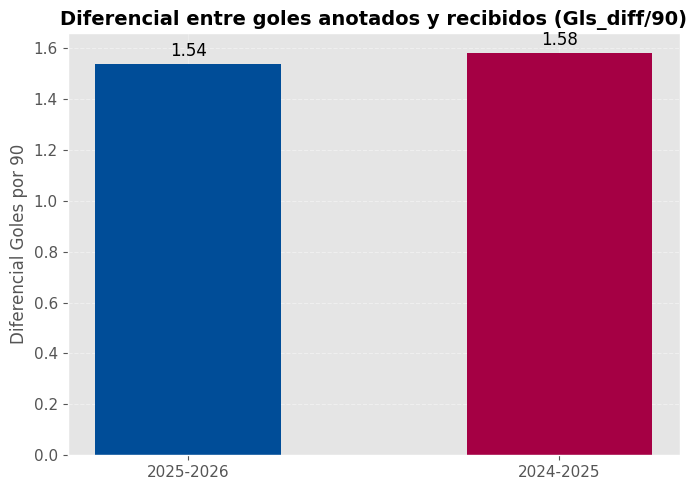

In [ ]:
pltn.bar_compare(df, "Gls_diff_per90", "Diferencial Goles por 90",
            "Diferencial entre goles anotados y recibidos (Gls_diff/90)")


El indicador Gls_diff_per90 mide cuántos goles más (o menos) marca el equipo respecto a los que recibe por partido. Es el “saldo real” del rendimiento, sin modelos avanzados:

Gls_diff_per90 = Gls_per90 – GA_per90


En la temporada 2024/25, el Barça presentaba un diferencial de +1.58 goles por 90’, reflejo de un equipo claramente superior a sus rivales y con una estructura de juego muy sólida tanto en ataque como en defensa.

En 2025/26, el diferencial cae a +1.54, una ligera reducción que esconde un hecho importante:

El Barcelona mantiene su capacidad goleadora, pero empeora defensivamente, encajando más goles por partido.

Aunque pueda parecer una caída pequeña, es significativa en términos competitivos: un descenso en el diferencial real de goles suele anticipar más partidos ajustados, menos control y mayor dependencia del acierto individual.

In [ ]:
df = pd.read_csv("/home/fjordan/Documentos/Proyectos/Personales/Analisis_Barcelona/data/processed/matchlogs_with_keyplayers_2024-2025.csv")
df.head()


,Date,MatchURL,Time,Comp,Round,Day,Venue,Result,GF,GA,...,Notes,Pedri_played,Pedri_started,Pedri_minutes,Lamine Yamal_played,Lamine Yamal_started,Lamine Yamal_minutes,Íñigo Martínez_played,Íñigo Martínez_started,Íñigo Martínez_minutes
0,2024-08-17,https://fbref.com/en/matches/6f0fac43/Valencia...,21:30,La Liga,Matchweek 1,Sat,Away,W,2,1,...,NaN,1,0,0,1,1,0,1,1,0
1,2024-08-24,https://fbref.com/en/matches/87bc9bba/Barcelon...,19:00,La Liga,Matchweek 2,Sat,Home,W,2,1,...,NaN,1,1,0,1,1,0,1,1,0
2,2024-08-27,https://fbref.com/en/matches/f8fc00c7/Rayo-Val...,21:30,La Liga,Matchweek 3,Tue,Away,W,2,1,...,NaN,1,1,0,1,1,0,1,1,0
3,2024-08-31,https://fbref.com/en/matches/3ed1b8ff/Barcelon...,17:00,La Liga,Matchweek 4,Sat,Home,W,7,0,...,NaN,1,1,0,1,1,0,1,1,0
4,2024-09-15,https://fbref.com/en/matches/f166ffc9/Girona-B...,16:15,La Liga,Matchweek 5,Sun,Away,W,4,1,...,NaN,1,1,0,1,1,0,1,1,0


In [ ]:
impact_pedri = at.analyze_player_impact(df, "Pedri")
impact_lamine = at.analyze_player_impact(df, "Lamine Yamal")
impact_inigo = at.analyze_player_impact(df, "Íñigo Martínez")

impact_pedri, impact_lamine, impact_inigo

({'PPG_con': np.float64(2.305084745762712),
  'PPG_sin': np.float64(3.0),
  'xG_con': np.float64(2.33921568627451),
  'xG_sin': np.float64(4.4),
  'GF_con': np.float64(2.830508474576271),
  'GF_sin': np.float64(7.0),
  'xGA_con': np.float64(1.2039215686274511),
  'xGA_sin': np.float64(1.5),
  'GA_con': np.float64(1.2033898305084745),
  'GA_sin': np.float64(1.0),
  'Partidos_con': 59,
  'Partidos_sin': 1},
 {'PPG_con': np.float64(2.4),
  'PPG_sin': np.float64(1.4),
  'xG_con': np.float64(2.410416666666667),
  'xG_sin': np.float64(2.0),
  'GF_con': np.float64(2.981818181818182),
  'GF_sin': np.float64(2.0),
  'xGA_con': np.float64(1.2),
  'xGA_sin': np.float64(1.325),
  'GA_con': np.float64(1.2181818181818183),
  'GA_sin': np.float64(1.0),
  'Partidos_con': 55,
  'Partidos_sin': 5},
 {'PPG_con': np.float64(2.339622641509434),
  'PPG_sin': np.float64(2.142857142857143),
  'xG_con': np.float64(2.3695652173913047),
  'xG_sin': np.float64(2.45),
  'GF_con': np.float64(2.849056603773585),
  '

In [ ]:
impact_pedri

{'PPG_con': np.float64(2.305084745762712),
 'PPG_sin': np.float64(3.0),
 'xG_con': np.float64(2.33921568627451),
 'xG_sin': np.float64(4.4),
 'GF_con': np.float64(2.830508474576271),
 'GF_sin': np.float64(7.0),
 'xGA_con': np.float64(1.2039215686274511),
 'xGA_sin': np.float64(1.5),
 'GA_con': np.float64(1.2033898305084745),
 'GA_sin': np.float64(1.0),
 'Partidos_con': 59,
 'Partidos_sin': 1}

/home/fjordan/Documentos/Proyectos/Personales/Analisis_Barcelona/src/Plots_notebook.py:232: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=values, palette=palette, ax=ax)


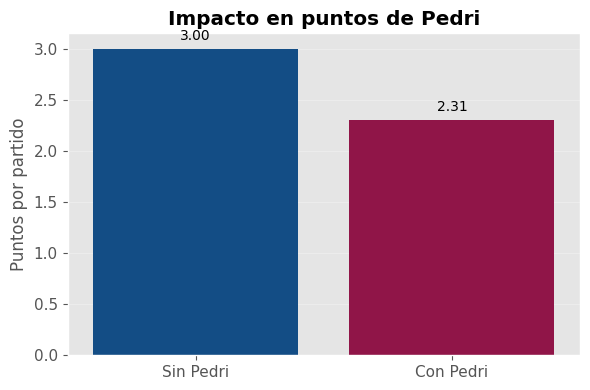

In [ ]:
fig1, ax1 = pltn.plot_points_impact(impact_pedri, player_name="Pedri")

In [ ]:
import pandas as pd
df = pd.read_csv("/home/fjordan/Documentos/Proyectos/Personales/Analisis_Barcelona/data/processed/matchlogs_with_keyplayers_2025-2026.csv")
df[["Date", "Opponent", "Result"]].head(20)


,Date,Opponent,Result
0,2025-08-16,Mallorca,W
1,2025-08-23,Levante,W
2,2025-08-31,Rayo Vallecano,D
3,2025-09-14,Valencia,W
4,2025-09-18,eng Newcastle Utd,W
5,2025-09-21,Getafe,W
6,2025-09-25,Oviedo,W
7,2025-09-28,Real Sociedad,W
8,2025-10-01,fr Paris S-G,L
9,2025-10-05,Sevilla,L


Guardado final: /home/fjordan/Documentos/Proyectos/Personales/Analisis_Barcelona/data/processed/matchlogs_with_keyplayers_2025-2026.csv_fixed.csv
Partidos totales válidos: 19
Con Pedri: 1 Sin Pedri: 18
Puntos promedio con Pedri:  3.0
Puntos promedio sin Pedri:  2.111111111111111


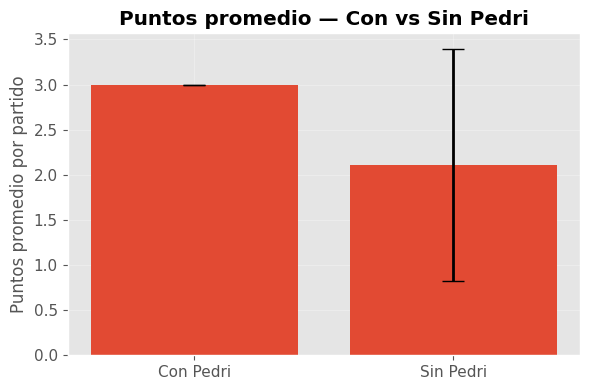

/tmp/ipykernel_11631/1757796667.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, patch_artist=True)


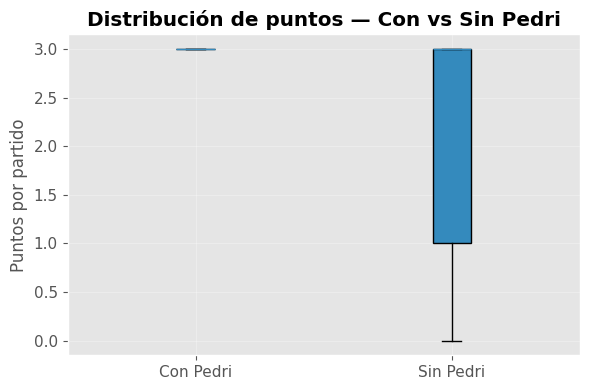

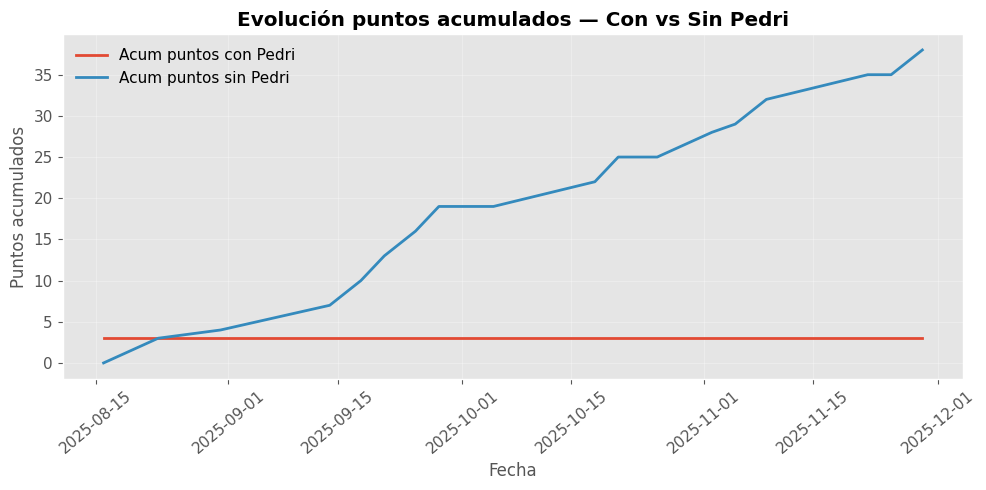

No hay suficientes partidos en uno de los grupos para t-test (mínimo 2 por grupo).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats   # si no lo tienes, pip install scipy

# --- 1) Si ya tienes df_out en memoria (resultado del debug), guarda ---
# Si ejecutaste el bloque anterior, df_out existe. Si no, carga el que hayas generado.
try:
    df_out  # noqa
except NameError:
    df_out = pd.read_csv("/home/fjordan/Documentos/Proyectos/Personales/Analisis_Barcelona/data/processed/matchlogs_clean_2025-2026.csv", dtype=str).fillna("")
    print("Cargado matchlogs clean; WARNING: si no has reconstruido flags, corre el bloque anterior primero.")

# Guardar resultado final (opcional: sobrescribe el anterior)
out_path = "/home/fjordan/Documentos/Proyectos/Personales/Analisis_Barcelona/data/processed/matchlogs_with_keyplayers_2025-2026.csv_fixed.csv"
df_out.to_csv(out_path, index=False)
print("Guardado final:", out_path)

# --- 2) Función segura para convertir Result -> points (tu formato: 'W','D','L' o NaN) ---
def result_to_points(res):
    if not isinstance(res, str):
        return np.nan
    r = res.strip().upper()
    if r == "W":
        return 3
    if r == "D":
        return 1
    if r == "L":
        return 0
    return np.nan

df_out["points"] = df_out["Result"].apply(result_to_points)

# filtrar partidos válidos (descartar NaN en points)
df_valid = df_out[df_out["points"].notna()].copy()
df_valid["points"] = df_valid["points"].astype(int)

# convertir flags a int por si acaso
df_valid["Pedri_played"] = pd.to_numeric(df_valid["Pedri_played"], errors="coerce").fillna(0).astype(int)

# --- 3) Resumen numérico ---
with_p = df_valid[df_valid["Pedri_played"] == 1]
without_p = df_valid[df_valid["Pedri_played"] == 0]

print("Partidos totales válidos:", len(df_valid))
print("Con Pedri:", len(with_p), "Sin Pedri:", len(without_p))
print("Puntos promedio con Pedri: ", with_p["points"].mean() if len(with_p)>0 else np.nan)
print("Puntos promedio sin Pedri: ", without_p["points"].mean() if len(without_p)>0 else np.nan)

# --- 4) Gráfico 1: barras con medias y std ---
means = [with_p["points"].mean() if len(with_p)>0 else 0, without_p["points"].mean() if len(without_p)>0 else 0]
stds = [with_p["points"].std(ddof=0) if len(with_p)>1 else 0, without_p["points"].std(ddof=0) if len(without_p)>1 else 0]
labels = ["Con Pedri", "Sin Pedri"]

plt.figure(figsize=(6,4))
plt.bar(labels, means, yerr=stds, capsize=8)
plt.ylabel("Puntos promedio por partido")
plt.title("Puntos promedio — Con vs Sin Pedri")
plt.tight_layout()
plt.show()

# --- 5) Gráfico 2: boxplot (distribución de puntos por partido) ---
plt.figure(figsize=(6,4))
data = [with_p["points"].values, without_p["points"].values]
plt.boxplot(data, labels=labels, patch_artist=True)
plt.ylabel("Puntos por partido")
plt.title("Distribución de puntos — Con vs Sin Pedri")
plt.tight_layout()
plt.show()

# --- 6) Gráfico 3: evolución acumulada de puntos (cumsum) ---
# ordenar por fecha
df_valid["Date_only"] = pd.to_datetime(df_valid["Date"], errors="coerce").dt.date
df_valid = df_valid.sort_values("Date_only")
df_valid["cum_with"] = (df_valid["points"] * (df_valid["Pedri_played"]==1)).cumsum()
df_valid["cum_without"] = (df_valid["points"] * (df_valid["Pedri_played"]==0)).cumsum()

plt.figure(figsize=(10,5))
plt.plot(df_valid["Date_only"], df_valid["cum_with"], label="Acum puntos con Pedri")
plt.plot(df_valid["Date_only"], df_valid["cum_without"], label="Acum puntos sin Pedri")
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Puntos acumulados")
plt.title("Evolución puntos acumulados — Con vs Sin Pedri")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

# --- 7) (Opcional) test estadístico simple: t-test (two-sample) ---
if len(with_p)>=2 and len(without_p)>=2:
    tstat, pval = stats.ttest_ind(with_p["points"], without_p["points"], equal_var=False, nan_policy="omit")
    print("t-test (con vs sin Pedri): t =", tstat, " p =", pval)
else:
    print("No hay suficientes partidos en uno de los grupos para t-test (mínimo 2 por grupo).")


In [4]:
import pandas as pd
df = pd.read_csv("/home/fjordan/Documentos/Proyectos/Personales/Analisis_Barcelona/data/processed/barca_lineups_2025-2026_fixed.csv", dtype=str).fillna("")
print(df[df["Player"].str.contains("Pedri", case=False)].head(20).to_string(index=False))


      Date         Comp          Opponent Result  GF  GA  xG xGA     MatchURL Player Shirt     Role Started OnBench Minutes
2025-08-16      La Liga          Mallorca      W 3.0 0.0 2.1 0.2 Match Report  Pedri     8 starters       1       0        
2025-08-23      La Liga           Levante      W 3.0 2.0 1.9 1.8 Match Report  Pedri     8 starters       1       0        
2025-08-31      La Liga    Rayo Vallecano      D 1.0 1.0 1.8 1.8 Match Report  Pedri     8 starters       1       0        
2025-09-14      La Liga          Valencia      W 6.0 0.0 3.9 0.1 Match Report  Pedri     8 starters       1       0        
2025-09-18 Champions Lg eng Newcastle Utd      W 2.0 1.0 1.1 1.2 Match Report  Pedri     8 starters       1       0        
2025-09-21      La Liga            Getafe      W 3.0 0.0 2.0 0.2 Match Report  Pedri     8 starters       1       0        
2025-09-25      La Liga            Oviedo      W 3.0 1.0 2.0 1.0 Match Report  Pedri     8 starters       1       0        
2025-09-

In [8]:
dfm = pd.read_csv("/home/fjordan/Documentos/Proyectos/Personales/Analisis_Barcelona/data/processed/matchlogs_with_keyplayers_2025-2026.csv", dtype=str).fillna("")
print(dfm[["Date","Opponent","Pedri_played","Pedri_started","Pedri_minutes"]].head(10).to_string(index=False))


      Date          Opponent Pedri_played Pedri_started Pedri_minutes
2025-08-16          Mallorca            0             0             0
2025-08-23           Levante            0             0             0
2025-08-31    Rayo Vallecano            0             0             0
2025-09-14          Valencia            0             0             0
2025-09-18 eng Newcastle Utd            0             0             0
2025-09-21            Getafe            0             0             0
2025-09-25            Oviedo            0             0             0
2025-09-28     Real Sociedad            0             0             0
2025-10-01      fr Paris S-G            0             0             0
2025-10-05           Sevilla            0             0             0
